In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,5)
sns.set_style("whitegrid")

In [2]:
fund_master = pd.read_csv("01_fund_master (1).csv")
nav = pd.read_csv("02_nav_history (1).csv")
aum = pd.read_csv("03_aum_by_fund_house (1).csv")
sip = pd.read_csv("04_monthly_sip_inflows (1).csv")
category = pd.read_csv("05_category_inflows (1).csv")
folio = pd.read_csv("06_industry_folio_count (1).csv")
performance = pd.read_csv("07_scheme_performance (1).csv")
transactions = pd.read_csv("08_investor_transactions (1).csv")
portfolio = pd.read_csv("09_portfolio_holdings (1).csv")
benchmark = pd.read_csv("10_benchmark_indices (1).csv")

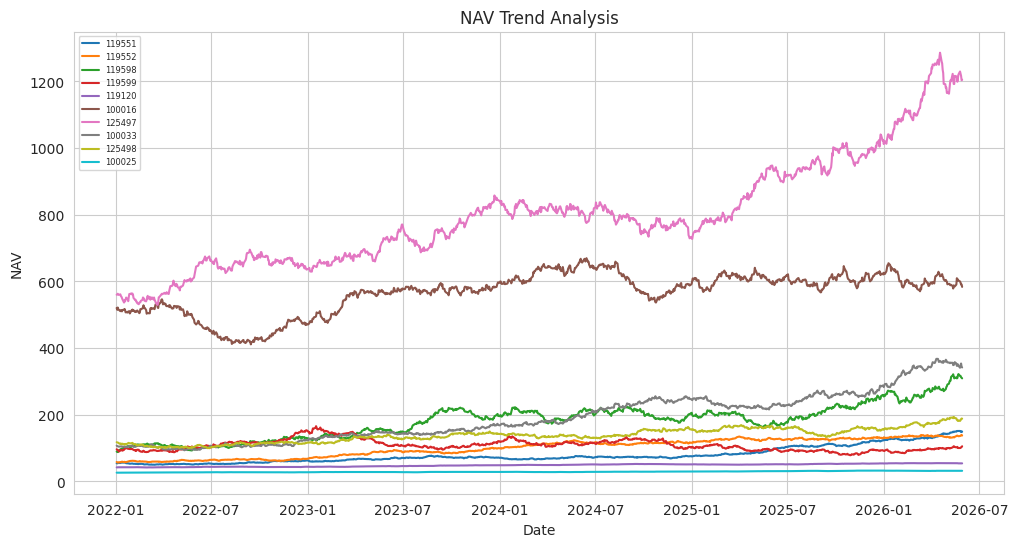

In [3]:
# NAV Trend Analysis

nav['date'] = pd.to_datetime(nav['date'])

plt.figure(figsize=(12,6))

for code in nav['amfi_code'].unique()[:10]:   # First 10 funds for clarity
    temp = nav[nav['amfi_code'] == code]
    plt.plot(temp['date'], temp['nav'], label=str(code))

plt.title("NAV Trend Analysis")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend(fontsize=6)

plt.savefig("Chart_1_NAV_Trend.png")
plt.show()

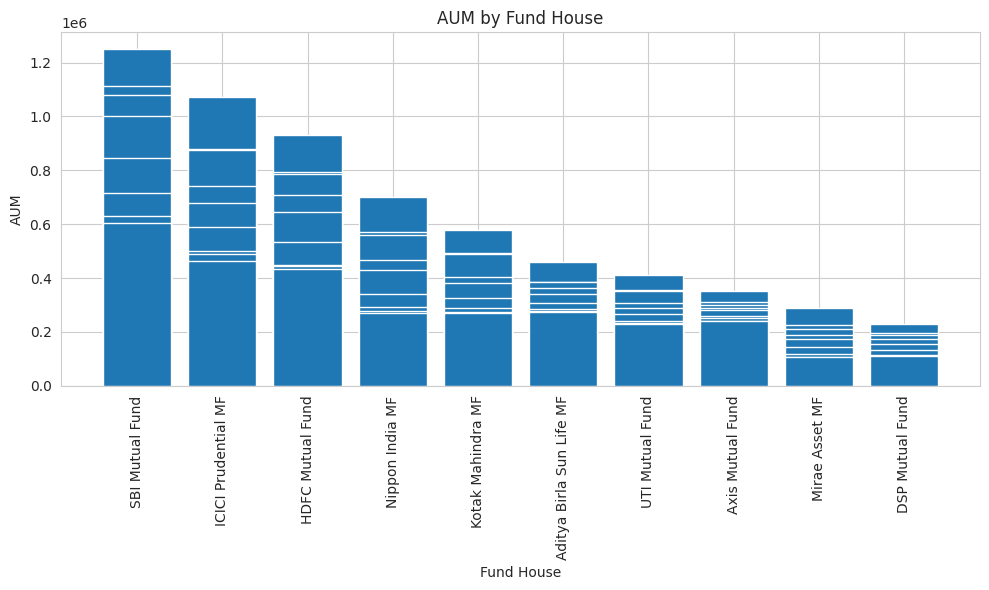

In [5]:
plt.figure(figsize=(10,6))

aum = aum.sort_values(by='aum_crore', ascending=False)

plt.bar(aum['fund_house'], aum['aum_crore'])

plt.xticks(rotation=90)

plt.title("AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM")

plt.tight_layout()

plt.savefig("Chart_2_AUM.png")

plt.show()

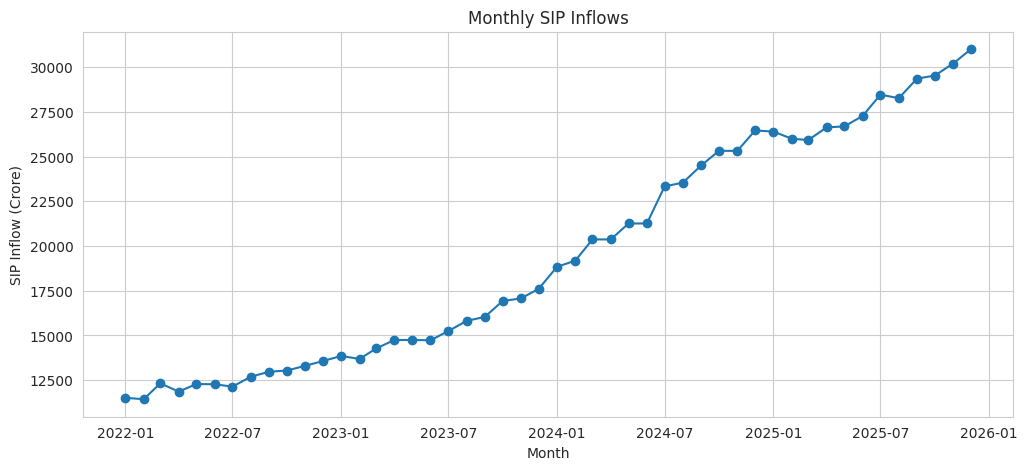

In [7]:
sip['month'] = pd.to_datetime(sip['month'])

plt.figure(figsize=(12,5))

plt.plot(sip['month'], sip['sip_inflow_crore'], marker='o')

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")

plt.grid(True)

plt.savefig("Chart_3_SIP.png")

plt.show()

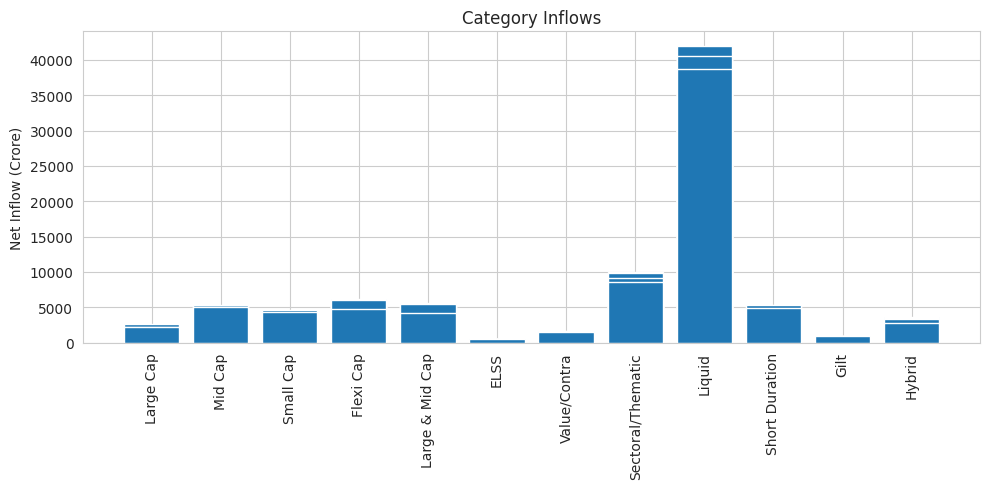

In [9]:
plt.figure(figsize=(10,5))

plt.bar(category['category'], category['net_inflow_crore'])

plt.xticks(rotation=90)

plt.title("Category Inflows")
plt.ylabel("Net Inflow (Crore)")

plt.tight_layout()

plt.savefig("Chart_4_Category.png")

plt.show()

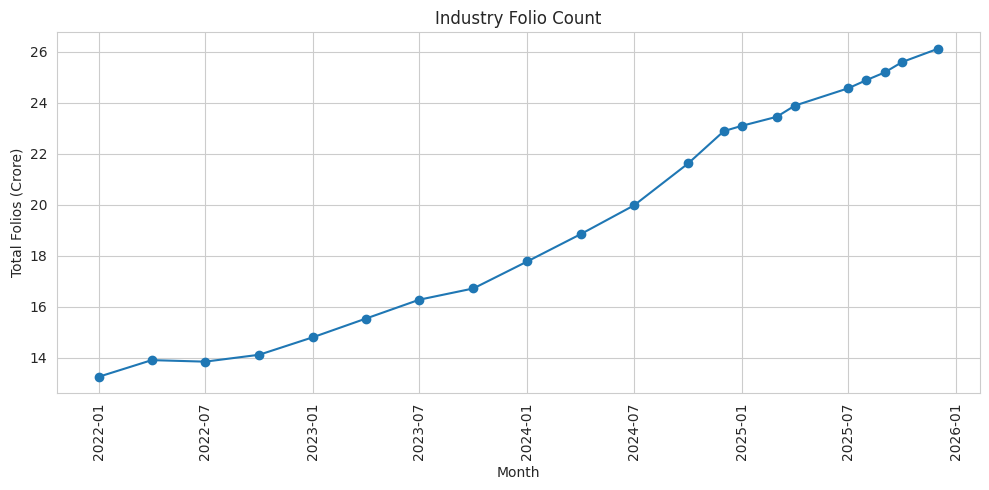

In [11]:
folio['month'] = pd.to_datetime(folio['month'])

plt.figure(figsize=(10,5))

plt.plot(folio['month'], folio['total_folios_crore'], marker='o')

plt.xticks(rotation=90)

plt.title("Industry Folio Count")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.tight_layout()

plt.savefig("Chart_5_Folio.png")

plt.show()

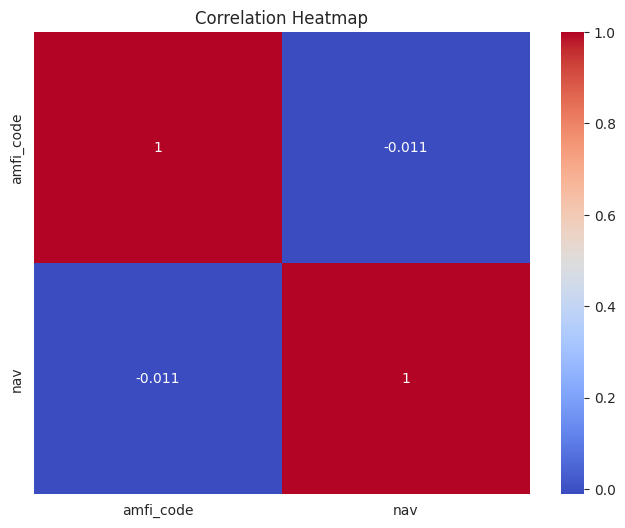

In [12]:
numeric_data = nav.select_dtypes(include='number')

plt.figure(figsize=(8,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("Chart_6_Correlation_Heatmap.png")
plt.show()

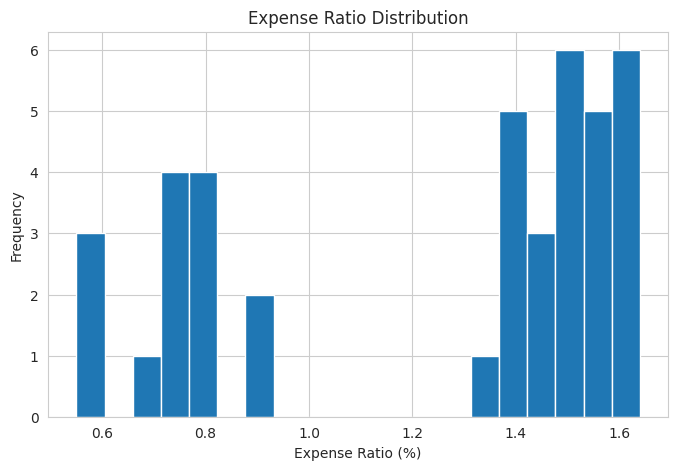

In [21]:
plt.figure(figsize=(8,5))

plt.hist(performance['expense_ratio_pct'], bins=20)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Frequency")

plt.savefig("Chart_7_Expense_Ratio.png")
plt.show()

In [20]:
print(performance.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


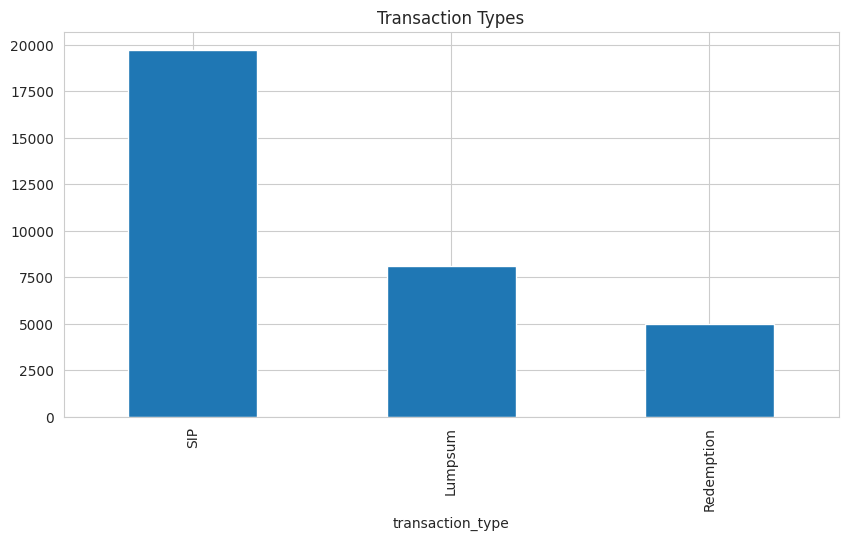

In [14]:
transactions['transaction_type'].value_counts().plot(kind='bar')

plt.title("Transaction Types")

plt.savefig("Chart_8_Transaction_Type.png")
plt.show()

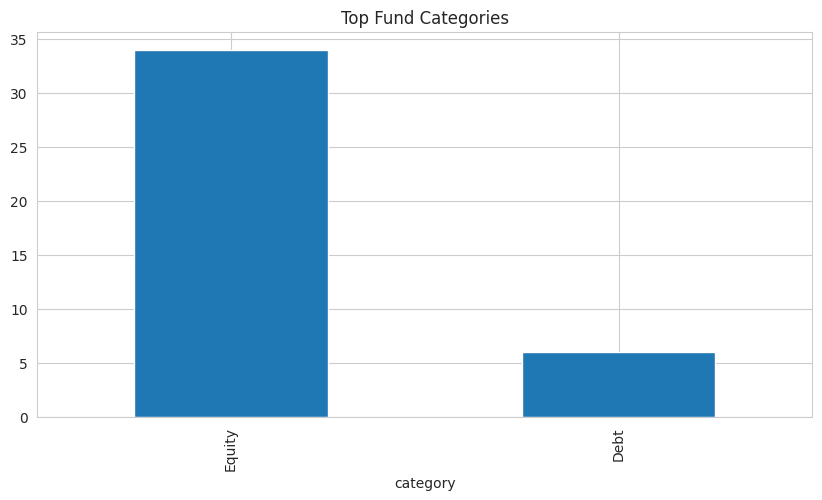

In [15]:
fund_master['category'].value_counts().head(10).plot(kind='bar')

plt.title("Top Fund Categories")

plt.savefig("Chart_9_Categories.png")
plt.show()

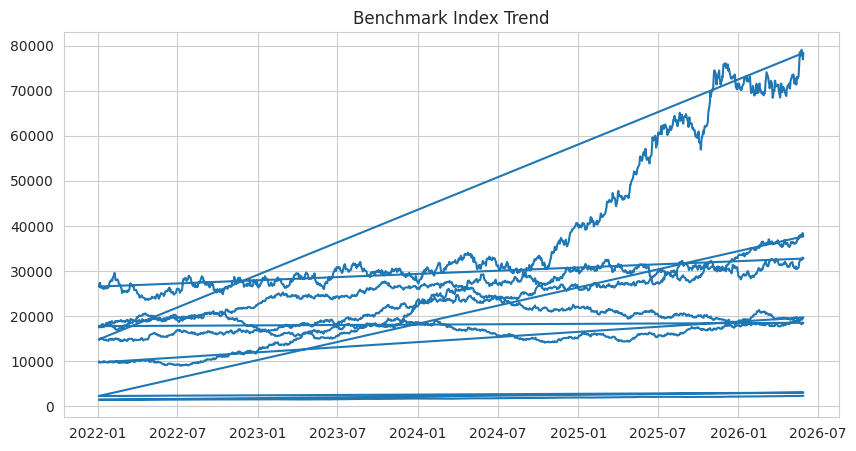

In [22]:
benchmark['date'] = pd.to_datetime(benchmark['date'])

plt.figure(figsize=(10,5))

plt.plot(benchmark['date'], benchmark['close_value'])

plt.title("Benchmark Index Trend")

plt.savefig("Chart_10_Benchmark.png")

plt.show()

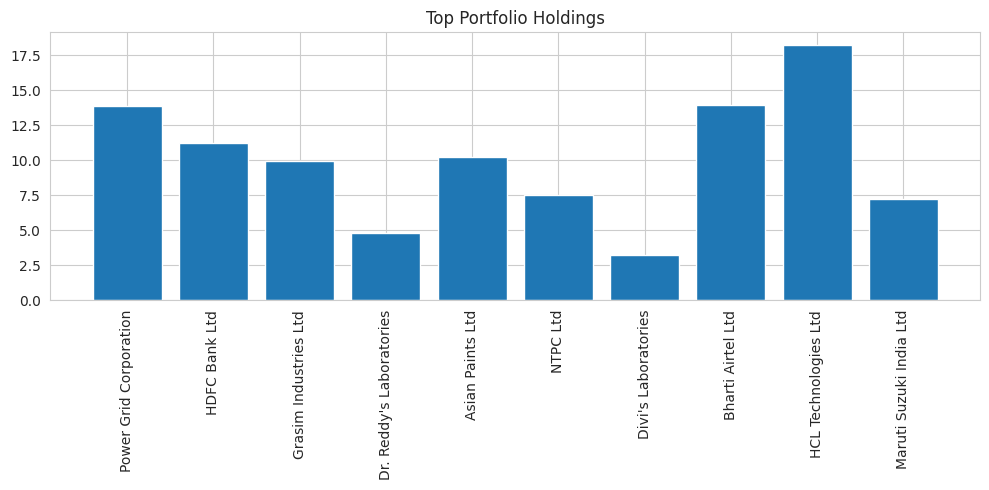

In [24]:
top_holdings = portfolio.head(10)

plt.figure(figsize=(10,5))

plt.bar(top_holdings['stock_name'], top_holdings['weight_pct'])

plt.xticks(rotation=90)

plt.title("Top Portfolio Holdings")

plt.tight_layout()

plt.savefig("Chart_11_Portfolio.png")

plt.show()

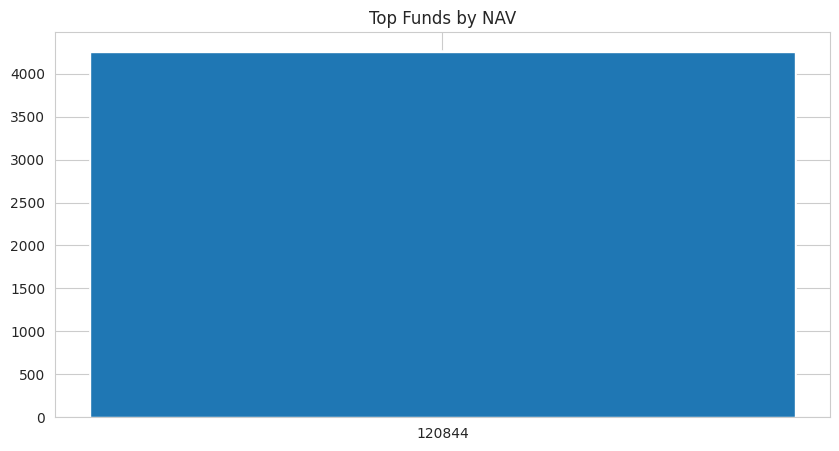

In [25]:
top_nav = nav.sort_values(by='nav', ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.bar(top_nav['amfi_code'].astype(str), top_nav['nav'])

plt.title("Top Funds by NAV")

plt.savefig("Chart_12_Top_NAV.png")

plt.show()

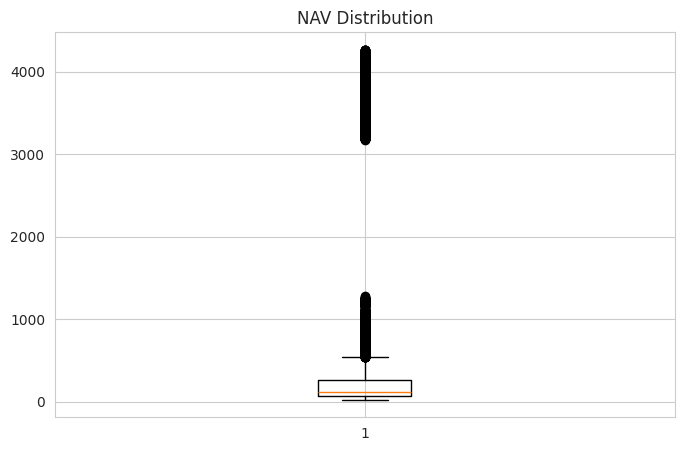

In [26]:
plt.figure(figsize=(8,5))

plt.boxplot(nav['nav'])

plt.title("NAV Distribution")

plt.savefig("Chart_13_NAV_Boxplot.png")

plt.show()

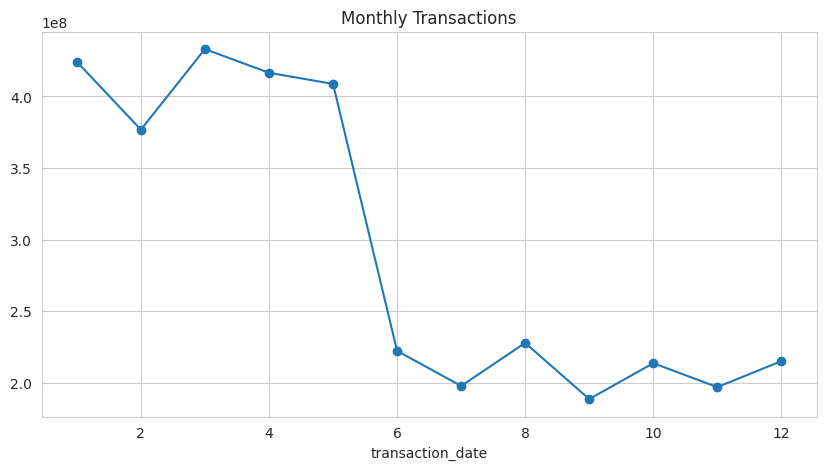

In [28]:
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

monthly = transactions.groupby(
    transactions['transaction_date'].dt.month
)['amount_inr'].sum()

monthly.plot(marker='o')

plt.title("Monthly Transactions")

plt.savefig("Chart_14_Monthly_Transactions.png")

plt.show()

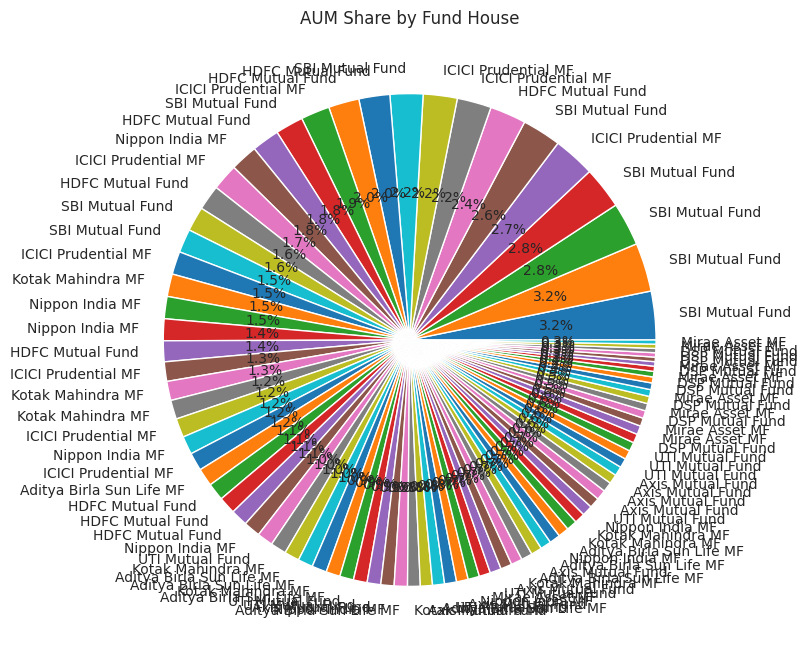

In [30]:
plt.figure(figsize=(8,8))

plt.pie(
    aum['aum_crore'],
    labels=aum['fund_house'],
    autopct='%1.1f%%'
)

plt.title("AUM Share by Fund House")

plt.savefig("Chart_15_AUM_Pie.png")

plt.show()

# Key EDA Findings

1. NAV values show an overall increasing trend across most mutual funds.
2. AUM is concentrated among a few leading fund houses.
3. SIP inflows demonstrate consistent long-term growth.
4. Some fund categories receive significantly higher inflows than others.
5. Expense ratios vary across schemes but remain within expected ranges.
6. Transaction patterns indicate a mix of SIP, Lumpsum, and Redemption activities.
7. Portfolio holdings are concentrated in selected sectors and companies.
8. Benchmark indices reflect overall market movements over time.
9. Correlation analysis highlights relationships among numerical variables.
10. The cleaned datasets are suitable for advanced analytics and visualization.